Loading data...
  Loaded 3900 rows × 24 columns
  Participants: 13

  Total valid trials:              3874
  Different-category trials:       1953 (50.4%)
  SD rate (failed to switch):      52.84%
  Correct switch rate:             47.16%

Cosine similarity analysis (different-category trials only)...
  Mean cosine sim — SD trials:     0.7143
  Mean cosine sim — no-SD trials:  0.7087
  Mann-Whitney U p =               0.1331

Transition direction analysis...
  Mal→Ben: SD rate=0.514  n=977  cosine→SD r=0.039 p=0.2226
  Ben→Mal: SD rate=0.543  n=976  cosine→SD r=0.030 p=0.3475
  Direction difference MWU p = 0.1961
  Cosine-only logistic AUC:        0.520
  Point-biserial r (cos ~ SD):     r = 0.019, p = 0.3959

Transition direction analysis...
  Mal→Ben: SD rate=0.514  n=977  cosine→SD r=0.039 p=0.2226
  Ben→Mal: SD rate=0.543  n=976  cosine→SD r=0.030 p=0.3475
  Direction difference MWU p = 0.1961

Extracting features (different-category trials only)...
  Feature matrix: 1953 trials ×

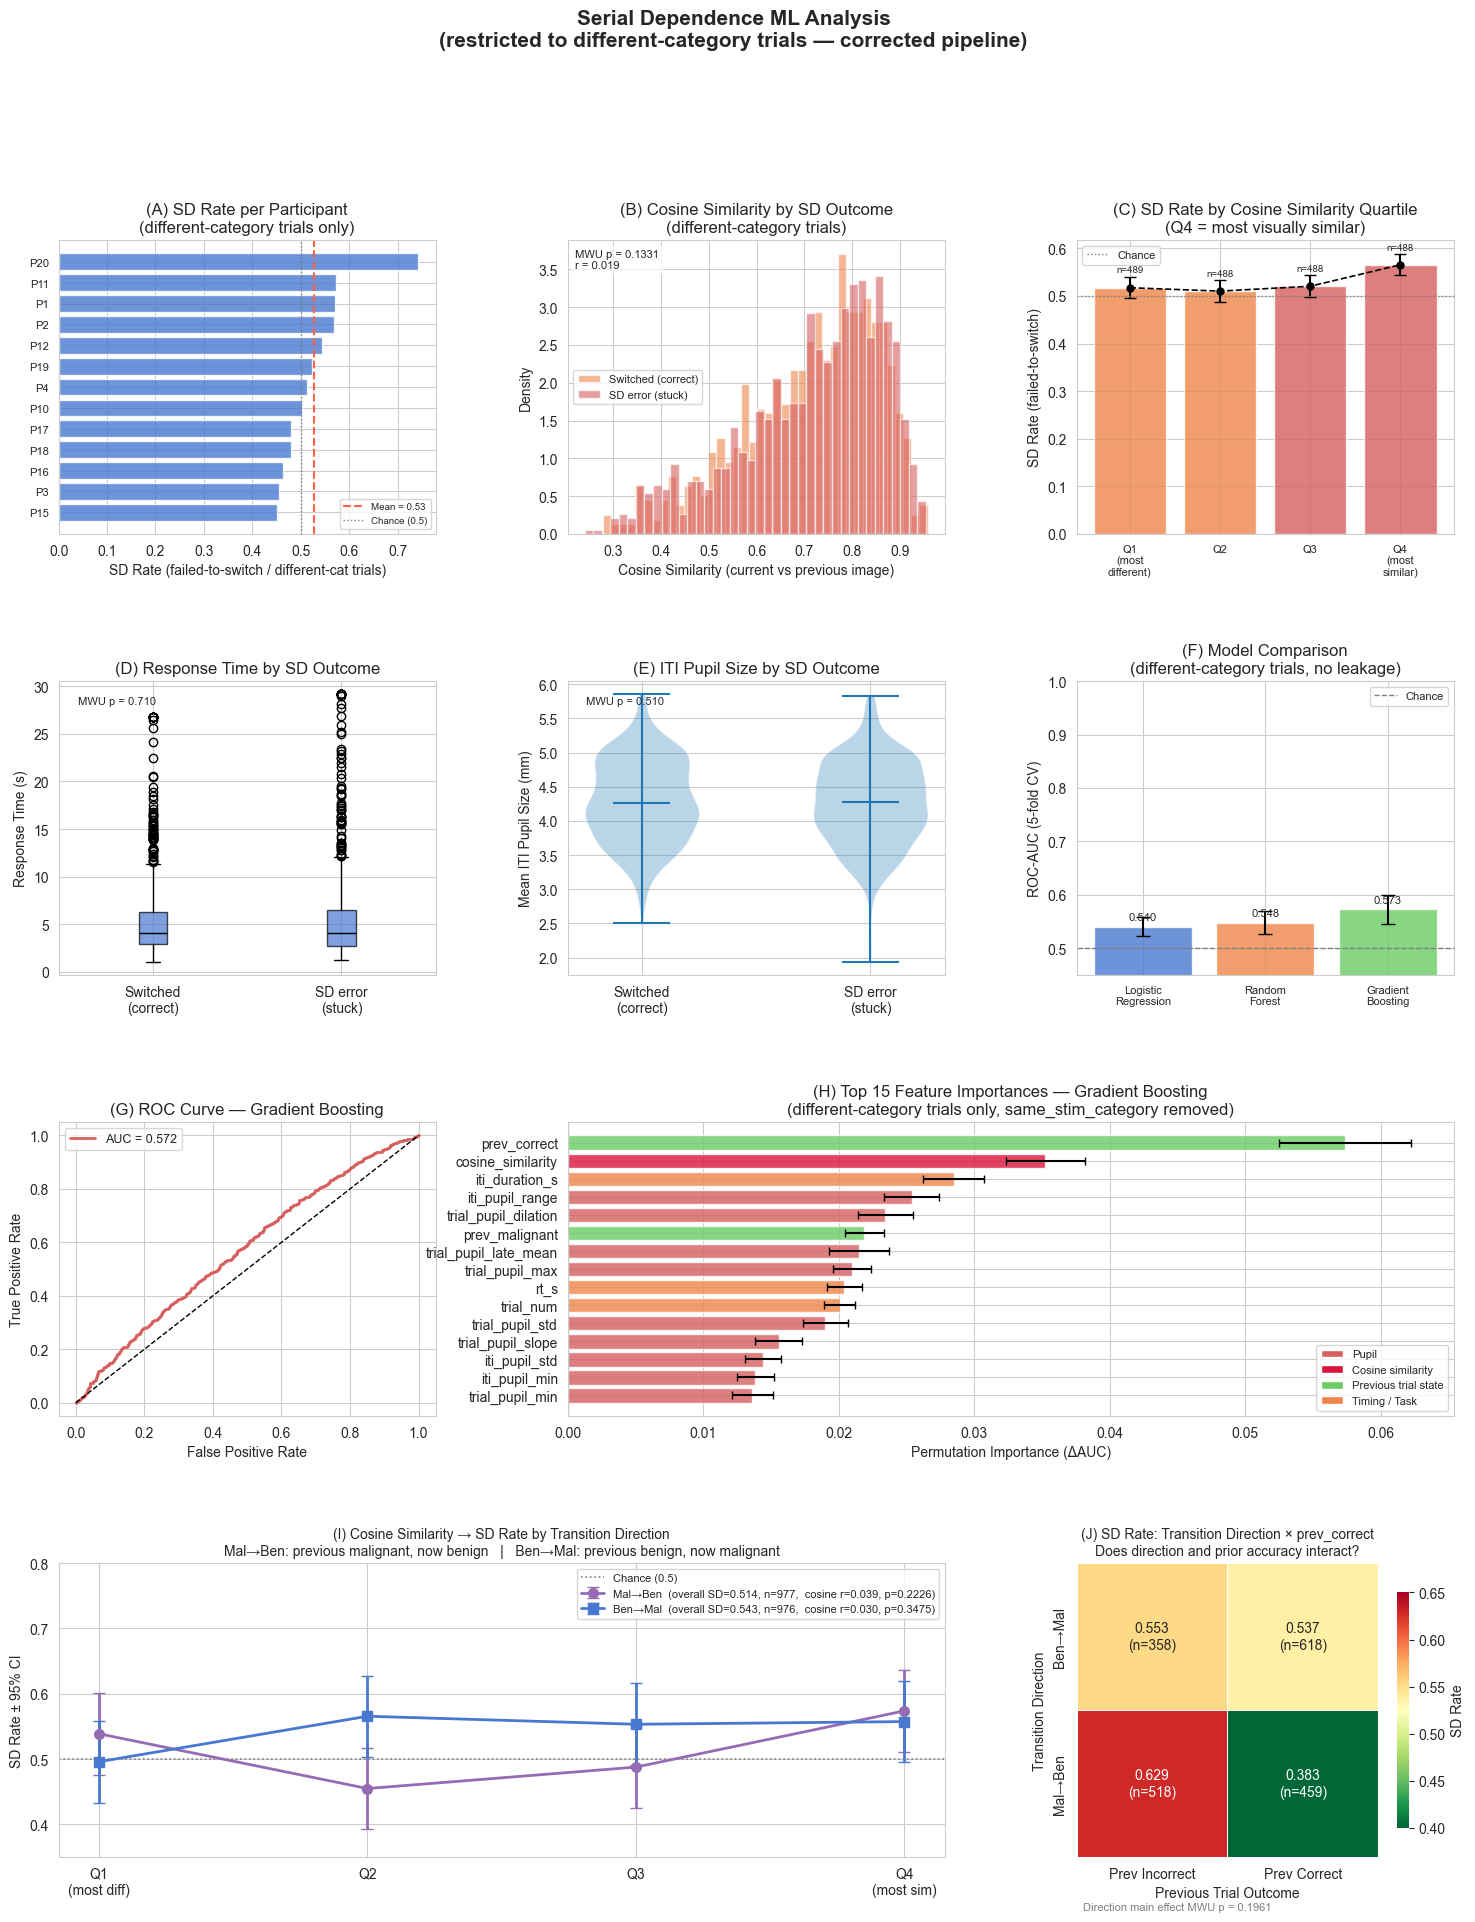

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

# Load data
print("Loading data...")
df = pd.read_pickle("all_data_et.pkl")
print(f"  Loaded {len(df)} rows × {df.shape[1]} columns")
print(f"  Participants: {df['participant'].nunique()}")

# Filter to different-category trials only
df_all = df[df["same_session"] == 1].copy()
df_all = df_all.dropna(subset=["n_min_1_response", "response", "stimulus", "n_min_1_stimulus"])

df_all["resp_binary"]      = (df_all["response"] == "malignant").astype(int)
df_all["prev_resp_binary"] = (df_all["n_min_1_response"] == "malignant").astype(int)
df_all["stim_binary"]      = (df_all["stimulus"] == "malignant").astype(int)
df_all["prev_stim_binary"] = (df_all["n_min_1_stimulus"] == "malignant").astype(int)
df_all["stim_changed"]     = (df_all["stim_binary"] != df_all["prev_stim_binary"]).astype(int)

# Filter for category change
df_sd = df_all[df_all["stim_changed"] == 1].copy()

# target: 1 means they stuck with the previous response
df_sd["sd_event"] = (df_sd["resp_binary"] == df_sd["prev_resp_binary"]).astype(int)

n_total     = len(df_all)
n_switched  = len(df_sd)
sd_rate     = df_sd["sd_event"].mean()

print(f"\n  Total valid trials:              {n_total}")
print(f"  Different-category trials:       {n_switched} ({n_switched/n_total:.1%})")
print(f"  SD rate (failed to switch):      {sd_rate:.2%}")
print(f"  Correct switch rate:             {1-sd_rate:.2%}")

# Cosine similarity stats
print("\nCosine similarity analysis (different-category trials only)...")

cos_sd  = df_sd.loc[df_sd["sd_event"] == 1, "cosine_similarity"].dropna()
cos_no  = df_sd.loc[df_sd["sd_event"] == 0, "cosine_similarity"].dropna()
mwu_stat, mwu_p = stats.mannwhitneyu(cos_sd, cos_no, alternative="two-sided")

print(f"  Mean cosine sim — SD trials:     {cos_sd.mean():.4f}")
print(f"  Mean cosine sim — no-SD trials:  {cos_no.mean():.4f}")
print(f"  Mann-Whitney U p =               {mwu_p:.4f}")

# Bin into quartiles
df_sd["cos_quartile"] = pd.qcut(df_sd["cosine_similarity"], q=4,
                                labels=["Q1\n(most\ndifferent)", "Q2", "Q3",
                                        "Q4\n(most\nsimilar)"])
cos_bin_rates = df_sd.groupby("cos_quartile", observed=True)["sd_event"].agg(["mean", "sem", "count"])

# Split by transition direction
df_sd["transition"] = np.where(
    (df_sd["prev_stim_binary"] == 1) & (df_sd["stim_binary"] == 0),
    "Mal→Ben", "Ben→Mal"
)

print("\nTransition direction analysis...")
for trans in ["Mal→Ben", "Ben→Mal"]:
    sub = df_sd[df_sd["transition"] == trans]
    r, p = stats.spearmanr(sub["cosine_similarity"], sub["sd_event"])
    print(f"  {trans}: SD rate={sub['sd_event'].mean():.3f}  "
          f"n={len(sub)}  cosine→SD r={r:.3f} p={p:.4f}")
_, p_trans = stats.mannwhitneyu(
    df_sd[df_sd["transition"] == "Mal→Ben"]["sd_event"],
    df_sd[df_sd["transition"] == "Ben→Mal"]["sd_event"],
    alternative="two-sided"
)
print(f"  Direction difference MWU p = {p_trans:.4f}")

# Quick baseline logistic regression
from sklearn.linear_model import LogisticRegression as LR
cos_vals = df_sd[["cosine_similarity"]].fillna(df_sd["cosine_similarity"].median())
lr_cos = LR().fit(StandardScaler().fit_transform(cos_vals), df_sd["sd_event"])
cos_auc = roc_auc_score(df_sd["sd_event"],
                        LR().fit(StandardScaler().fit_transform(cos_vals),
                                 df_sd["sd_event"]).predict_proba(
                               StandardScaler().fit_transform(cos_vals))[:, 1])
print(f"  Cosine-only logistic AUC:        {cos_auc:.3f}")

r_pb, p_pb = stats.pointbiserialr(df_sd["sd_event"], df_sd["cosine_similarity"].fillna(df_sd["cosine_similarity"].median()))
print(f"  Point-biserial r (cos ~ SD):      r = {r_pb:.3f}, p = {p_pb:.4f}")

# Helper to process pupil arrays
def pupil_features(ts_list, pup_list, prefix):
    feats = {}
    try:
        ts  = np.array(ts_list,  dtype=float)
        pup = np.array(pup_list, dtype=float)
        if len(pup) < 3:
            raise ValueError
        feats[f"{prefix}_mean"]       = np.nanmean(pup)
        feats[f"{prefix}_std"]        = np.nanstd(pup)
        feats[f"{prefix}_min"]        = np.nanmin(pup)
        feats[f"{prefix}_max"]        = np.nanmax(pup)
        feats[f"{prefix}_range"]      = np.nanmax(pup) - np.nanmin(pup)
        feats[f"{prefix}_slope"]      = np.polyfit(ts - ts[0], pup, 1)[0] if len(ts) > 1 else 0.0
        feats[f"{prefix}_final"]      = pup[-1]
        feats[f"{prefix}_early_mean"] = np.nanmean(pup[:len(pup)//3])
        feats[f"{prefix}_late_mean"]  = np.nanmean(pup[2*len(pup)//3:])
        feats[f"{prefix}_dilation"]   = feats[f"{prefix}_late_mean"] - feats[f"{prefix}_early_mean"]
    except Exception:
        for key in ["mean","std","min","max","range","slope",
                    "final","early_mean","late_mean","dilation"]:
            feats[f"{prefix}_{key}"] = np.nan
    return feats

print("\nExtracting features...")
conf_map = {"high": 1, "low": 0}
rows = []

for _, row in df_sd.iterrows():
    f = {}

    f["cosine_similarity"]   = row["cosine_similarity"]
    f["prev_confidence"]     = conf_map.get(row["n_min_1_confidence"], np.nan)
    f["prev_correct"]        = row.get("correct", np.nan)
    f["prev_malignant"]      = int(row["n_min_1_stimulus"] == "malignant")

    f["iti_duration_s"]      = row["iti_end_time_s"] - row["iti_start_time_s"]
    f["rt_s"]                = row["mouse_response_s"] - row["stimulus_onset_s"]
    f["trial_num"]           = row["trial_num"]
    f["block_num"]           = row["block_num"]

    f.update(pupil_features(row["iti_timestamp_s"],   row["iti_pupil"],   "iti_pupil"))
    f.update(pupil_features(row["trial_timestamp_s"], row["trial_pupil"], "trial_pupil"))

    if not np.isnan(f.get("iti_pupil_mean", np.nan)) and not np.isnan(f.get("trial_pupil_mean", np.nan)):
        f["pupil_task_vs_iti"] = f["trial_pupil_mean"] - f["iti_pupil_mean"]
    else:
        f["pupil_task_vs_iti"] = np.nan

    f["sd_event"]      = row["sd_event"]
    f["participant"]   = row["participant"]
    f["cos_quartile"]  = row["cos_quartile"]
    f["transition"]    = row["transition"]
    rows.append(f)

features_df = pd.DataFrame(rows)
print(f"  Feature matrix: {features_df.shape[0]} trials × {features_df.shape[1]} columns")

# Model Setup
TARGET       = "sd_event"
exclude_cols = [TARGET, "participant", "cos_quartile", "transition"]
feature_cols = [c for c in features_df.columns if c not in exclude_cols]

X = features_df[feature_cols].fillna(features_df[feature_cols].median())
y = features_df[TARGET]

print(f"\nTraining models (n={len(X)}, positive rate={y.mean():.2%})...")

models = {
    "Logistic\nRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, C=0.1, class_weight="balanced"))
    ]),
    "Random\nForest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=42))
    ]),
    "Gradient\nBoosting": Pipeline([
        ("clf", GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in models.items():
    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    accs = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    results[name] = {"auc_mean": aucs.mean(), "auc_std": aucs.std(),
                     "acc_mean": accs.mean(), "acc_std": accs.std()}
    print(f"  {name.replace(chr(10),' '):25s}  AUC {aucs.mean():.3f}±{aucs.std():.3f}  "
          f"Acc {accs.mean():.3f}±{accs.std():.3f}")

best_name = max(results, key=lambda k: results[k]["auc_mean"])
best_model = models[best_name]
best_model.fit(X, y)
print(f"\nBest model: {best_name.replace(chr(10),' ')}")

# Feature importance using permutation
print("Computing permutation importances...")
perm = permutation_importance(best_model, X, y, n_repeats=20, random_state=42, scoring="roc_auc")
imp_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).sort_values("importance", ascending=False)

print("\nTop 10 features:")
print(imp_df.head(10).to_string(index=False))

# Plotting setup
sns.set_style("whitegrid")
pal = sns.color_palette("muted")
fig = plt.figure(figsize=(18, 21)) 
fig.suptitle(
    "Serial Dependence ML Analysis\n(restricted to different-category trials — corrected pipeline)",
    fontsize=15, fontweight="bold", y=0.99
)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.50, wspace=0.35)

# (A) Participant SD rates
ax_a = fig.add_subplot(gs[0, 0])
part_sd = features_df.groupby("participant")["sd_event"].mean().sort_values()
ax_a.barh(range(len(part_sd)), part_sd.values, color=pal[0], alpha=0.8)
ax_a.set_yticks(range(len(part_sd)))
ax_a.set_yticklabels([f"P{int(p)}" for p in part_sd.index], fontsize=8)
ax_a.set_xlabel("SD Rate (failed-to-switch / different-cat trials)")
ax_a.set_title("(A) SD Rate per Participant\n(different-category trials only)")
ax_a.axvline(part_sd.mean(), color="tomato", ls="--", lw=1.5, label=f"Mean = {part_sd.mean():.2f}")
ax_a.axvline(0.5, color="gray", ls=":", lw=1, label="Chance (0.5)")
ax_a.legend(fontsize=7)

# (B) Cosine histograms
ax_b = fig.add_subplot(gs[0, 1])
ax_b.hist(cos_no,  bins=40, alpha=0.6, color=pal[1], density=True, label="Switched (correct)")
ax_b.hist(cos_sd,  bins=40, alpha=0.6, color=pal[3], density=True, label="SD error (stuck)")
ax_b.set_xlabel("Cosine Similarity (current vs previous image)")
ax_b.set_ylabel("Density")
ax_b.set_title("(B) Cosine Similarity by SD Outcome\n(different-category trials)")
ax_b.legend(fontsize=8)
ax_b.text(0.02, 0.97, f"MWU p = {mwu_p:.4f}\nr = {r_pb:.3f}",
          transform=ax_b.transAxes, fontsize=8, va="top",
          bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# (C) SD by cosine quartile
ax_c = fig.add_subplot(gs[0, 2])
x_pos  = range(len(cos_bin_rates))
colors = [pal[1], pal[1], pal[3], pal[3]]  
bars   = ax_c.bar(x_pos, cos_bin_rates["mean"], yerr=cos_bin_rates["sem"], color=colors, alpha=0.8, capsize=4)
ax_c.axhline(0.5, color="gray", ls=":", lw=1, label="Chance")
ax_c.set_xticks(x_pos)
ax_c.set_xticklabels(cos_bin_rates.index.tolist(), fontsize=8)
ax_c.set_ylabel("SD Rate (failed-to-switch)")
ax_c.set_title("(C) SD Rate by Cosine Similarity Quartile\n(Q4 = most visually similar)")
ax_c.legend(fontsize=8)
for bar, (_, brow) in zip(bars, cos_bin_rates.iterrows()):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + brow["sem"] + 0.005,
              f"n={int(brow['count'])}", ha="center", va="bottom", fontsize=7)
ax_c.plot(x_pos, cos_bin_rates["mean"], "k--o", lw=1.2, ms=5, zorder=5)

# (D) Response times
ax_d = fig.add_subplot(gs[1, 0])
rt_sd  = features_df.loc[features_df["sd_event"] == 1, "rt_s"].dropna()
rt_ok  = features_df.loc[features_df["sd_event"] == 0, "rt_s"].dropna()
ax_d.boxplot([rt_ok.clip(upper=rt_ok.quantile(0.99)).values,
              rt_sd.clip(upper=rt_sd.quantile(0.99)).values],
             labels=["Switched\n(correct)", "SD error\n(stuck)"],
             patch_artist=True, boxprops=dict(facecolor=pal[0], alpha=0.7), medianprops=dict(color="black"))
ax_d.set_ylabel("Response Time (s)")
ax_d.set_title("(D) Response Time by SD Outcome")
stat, p = stats.mannwhitneyu(rt_sd, rt_ok, alternative="two-sided")
ax_d.text(0.05, 0.95, f"MWU p = {p:.3f}", transform=ax_d.transAxes, fontsize=8, va="top")

# (E) Pupil violin plot
ax_e = fig.add_subplot(gs[1, 1])
pup_sd = features_df.loc[features_df["sd_event"] == 1, "iti_pupil_mean"].dropna()
pup_ok = features_df.loc[features_df["sd_event"] == 0, "iti_pupil_mean"].dropna()
ax_e.violinplot([pup_ok.values, pup_sd.values], positions=[0, 1], showmedians=True)
ax_e.set_xticks([0, 1])
ax_e.set_xticklabels(["Switched\n(correct)", "SD error\n(stuck)"])
ax_e.set_ylabel("Mean ITI Pupil Size (mm)")
ax_e.set_title("(E) ITI Pupil Size by SD Outcome")
stat, p = stats.mannwhitneyu(pup_sd, pup_ok, alternative="two-sided")
ax_e.text(0.05, 0.95, f"MWU p = {p:.3f}", transform=ax_e.transAxes, fontsize=8, va="top")

# (F) CV Model performance comparison
ax_f = fig.add_subplot(gs[1, 2])
model_names = list(results.keys())
aucs_mean   = [results[m]["auc_mean"] for m in model_names]
aucs_std    = [results[m]["auc_std"]  for m in model_names]
bars_f = ax_f.bar(model_names, aucs_mean, yerr=aucs_std, color=[pal[i] for i in range(len(model_names))], alpha=0.8, capsize=5)
ax_f.set_ylim(0.45, 1.0)
ax_f.axhline(0.5, color="gray", ls="--", lw=1, label="Chance")
ax_f.set_ylabel("ROC-AUC (5-fold CV)")
ax_f.set_title("(F) Model Comparison\n(different-category trials, no leakage)")
ax_f.set_xticklabels(model_names, rotation=0, fontsize=8)
ax_f.legend(fontsize=8)
for bar, val in zip(bars_f, aucs_mean):
    ax_f.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008, f"{val:.3f}", ha="center", va="bottom", fontsize=8)

# (G) ROC curve generation
ax_g = fig.add_subplot(gs[2, 0])
y_scores_list, y_test_list = [], []
for train_idx, test_idx in cv.split(X, y):
    best_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_scores_list.append(best_model.predict_proba(X.iloc[test_idx])[:, 1])
    y_test_list.append(y.iloc[test_idx].values)
y_scores_all = np.concatenate(y_scores_list)
y_test_all   = np.concatenate(y_test_list)
fpr, tpr, _ = roc_curve(y_test_all, y_scores_all)
auc_val      = roc_auc_score(y_test_all, y_scores_all)
ax_g.plot(fpr, tpr, color=pal[3], lw=2, label=f"AUC = {auc_val:.3f}")
ax_g.plot([0, 1], [0, 1], "k--", lw=1)
ax_g.set_xlabel("False Positive Rate")
ax_g.set_ylabel("True Positive Rate")
ax_g.set_title(f"(G) ROC Curve — {best_name.replace(chr(10), ' ')}")
ax_g.legend(fontsize=9)

# (H) Feature importance plotting
ax_h = fig.add_subplot(gs[2, 1:])
top15 = imp_df.head(15).sort_values("importance")
feat_colors = []
for feat in top15["feature"]:
    if "pupil" in feat:
        feat_colors.append(pal[3])
    elif feat == "cosine_similarity":
        feat_colors.append("crimson") 
    elif feat in ("prev_confidence", "prev_correct", "prev_malignant"):
        feat_colors.append(pal[2])
    else:
        feat_colors.append(pal[1])

bars_h = ax_h.barh(top15["feature"], top15["importance"], xerr=top15["std"], color=feat_colors, alpha=0.8, capsize=3)
ax_h.set_xlabel("Permutation Importance (ΔAUC)")
ax_h.set_title(f"(H) Top 15 Feature Importances — {best_name.replace(chr(10),' ')}")
legend_elements = [
    Patch(facecolor=pal[3],   label="Pupil"),
    Patch(facecolor="crimson",label="Cosine similarity"),
    Patch(facecolor=pal[2],   label="Previous trial state"),
    Patch(facecolor=pal[1],   label="Timing / Task"),
]
ax_h.legend(handles=legend_elements, fontsize=8, loc="lower right")
ax_h.axvline(0, color="gray", lw=0.8)

# (I) SD rate vs transition direction
ax_i = fig.add_subplot(gs[3, :2])
trans_colors  = {"Mal→Ben": pal[4], "Ben→Mal": pal[0]}
trans_markers = {"Mal→Ben": "o", "Ben→Mal": "s"}

for trans in ["Mal→Ben", "Ben→Mal"]:
    sub = features_df[features_df["transition"] == trans].copy()
    sd_rate_trans = sub["sd_event"].mean()
    sem_trans     = sub["sd_event"].sem()

    sub["cos_q"] = pd.qcut(sub["cosine_similarity"], q=4, labels=[1, 2, 3, 4])
    bin_r = sub.groupby("cos_q", observed=True)["sd_event"].agg(
        mean="mean", sem=lambda x: x.sem(), n="count"
    ).reset_index()

    r, p = stats.spearmanr(sub["cosine_similarity"].fillna(sub["cosine_similarity"].median()), sub["sd_event"])
    label = f"{trans}  (overall SD={sd_rate_trans:.3f}, n={len(sub)}, cosine r={r:.3f}, p={p:.4f})"
    ax_i.errorbar(
        bin_r["cos_q"].astype(int), bin_r["mean"], yerr=1.96 * bin_r["sem"],
        fmt=f"{trans_markers[trans]}-", color=trans_colors[trans], lw=2, ms=7, capsize=4, label=label
    )

ax_i.axhline(0.5, color="gray", ls=":", lw=1.2, label="Chance (0.5)")
ax_i.set_xticks([1, 2, 3, 4])
ax_i.set_xticklabels(["Q1\n(most diff)", "Q2", "Q3", "Q4\n(most sim)"])
ax_i.set_ylabel("SD Rate ± 95% CI")
ax_i.set_ylim(0.35, 0.80)
ax_i.set_title("(I) Cosine Similarity → SD Rate by Transition Direction", fontsize=10)
ax_i.legend(fontsize=8)

# (J) 2x2 Heatmap: direction vs prior accuracy
ax_j = fig.add_subplot(gs[3, 2])
heatmap_data = features_df.groupby(["transition", "prev_correct"], observed=True)["sd_event"].agg(mean="mean", n="count").reset_index()
pivot = heatmap_data.pivot(index="transition", columns="prev_correct", values="mean")
pivot.columns = ["Prev Incorrect", "Prev Correct"]
pivot.index.name = "Transition"

n_pivot = heatmap_data.pivot(index="transition", columns="prev_correct", values="n")
n_pivot.columns = ["Prev Incorrect", "Prev Correct"]

annot = pd.DataFrame(
    [[f"{pivot.loc[r, c]:.3f}\n(n={int(n_pivot.loc[r, c])})" for c in pivot.columns] for r in pivot.index],
    index=pivot.index, columns=pivot.columns
)

sns.heatmap(
    pivot, ax=ax_j, annot=annot, fmt="", cmap="RdYlGn_r", vmin=0.40, vmax=0.65,
    linewidths=0.5, linecolor="white", cbar_kws={"label": "SD Rate", "shrink": 0.8}, annot_kws={"fontsize": 10}
)
ax_j.set_title("(J) SD Rate: Transition Direction × prev_correct", fontsize=10)
ax_j.set_xlabel("Previous Trial Outcome")
ax_j.set_ylabel("Transition Direction")

stat_mb = features_df[features_df["transition"] == "Mal→Ben"]["sd_event"]
stat_bm = features_df[features_df["transition"] == "Ben→Mal"]["sd_event"]
_, p_dir = stats.mannwhitneyu(stat_mb, stat_bm, alternative="two-sided")
ax_j.text(0.02, -0.18, f"Direction main effect MWU p = {p_dir:.4f}", transform=ax_j.transAxes, fontsize=8, color="gray")

plt.savefig("serial_dependence_ml_results_v3.png", dpi=150, bbox_inches="tight")
print("\nFigure saved: serial_dependence_ml_results_v3.png")

# Metrics summary output
print("\n" + "="*65)
print("SUMMARY")
print("="*65)
print(f"\nDataset (different-category trials only):")
print(f"  N trials:         {len(X)}")
print(f"  SD rate:          {y.mean():.2%}  (failed to switch)")
print(f"\nCosine similarity effect:")
print(f"  Point-biserial r: {r_pb:.3f}  (p = {p_pb:.4f})")
print(f"  Cosine-only AUC:  {cos_auc:.3f}")
print(f"  Mean sim — SD:    {cos_sd.mean():.4f}")
print(f"  Mean sim — no SD: {cos_no.mean():.4f}")
print(f"\nBest model:  {best_name.replace(chr(10),' ')}")
print(f"  AUC (5-fold CV):  {results[best_name]['auc_mean']:.3f} ± {results[best_name]['auc_std']:.3f}")
print(f"\nTop predictors:")
for _, row in imp_df.head(10).iterrows():
    marker = "  ← cosine similarity" if row["feature"] == "cosine_similarity" else ""
    print(f"  {row['feature']:35s}  ΔAUC = {row['importance']:+.4f}{marker}")

Note: pingouin not installed — using scipy for post-hoc tests.
Loading data...
  Different-category trials: 1953
  SD rate: 0.528

── ANOVA: Cosine Similarity Quartiles ──

  One-way ANOVA: F = 1.2372,  p = 0.2946
  Kruskal-Wallis: H = 3.7104,  p = 0.2945

  SD rate per quartile:
    Q1
(most diff)        mean=0.5174  sem=0.0226  n=489
    Q2                    mean=0.5102  sem=0.0227  n=488
    Q3                    mean=0.5205  sem=0.0226  n=488
    Q4
(most sim)         mean=0.5656  sem=0.0225  n=488

  Post-hoc pairwise tests (Bonferroni-corrected):
    Q1 (most diff)     vs Q2                  p_raw=0.8236  p_bonf=1.0000  ns
    Q1 (most diff)     vs Q3                  p_raw=0.9227  p_bonf=1.0000  ns
    Q1 (most diff)     vs Q4 (most sim)       p_raw=0.1309  p_bonf=0.7853  ns
    Q2                 vs Q3                  p_raw=0.7490  p_bonf=1.0000  ns
    Q2                 vs Q4 (most sim)       p_raw=0.0832  p_bonf=0.4991  ns
    Q3                 vs Q4 (most sim)       p_ra

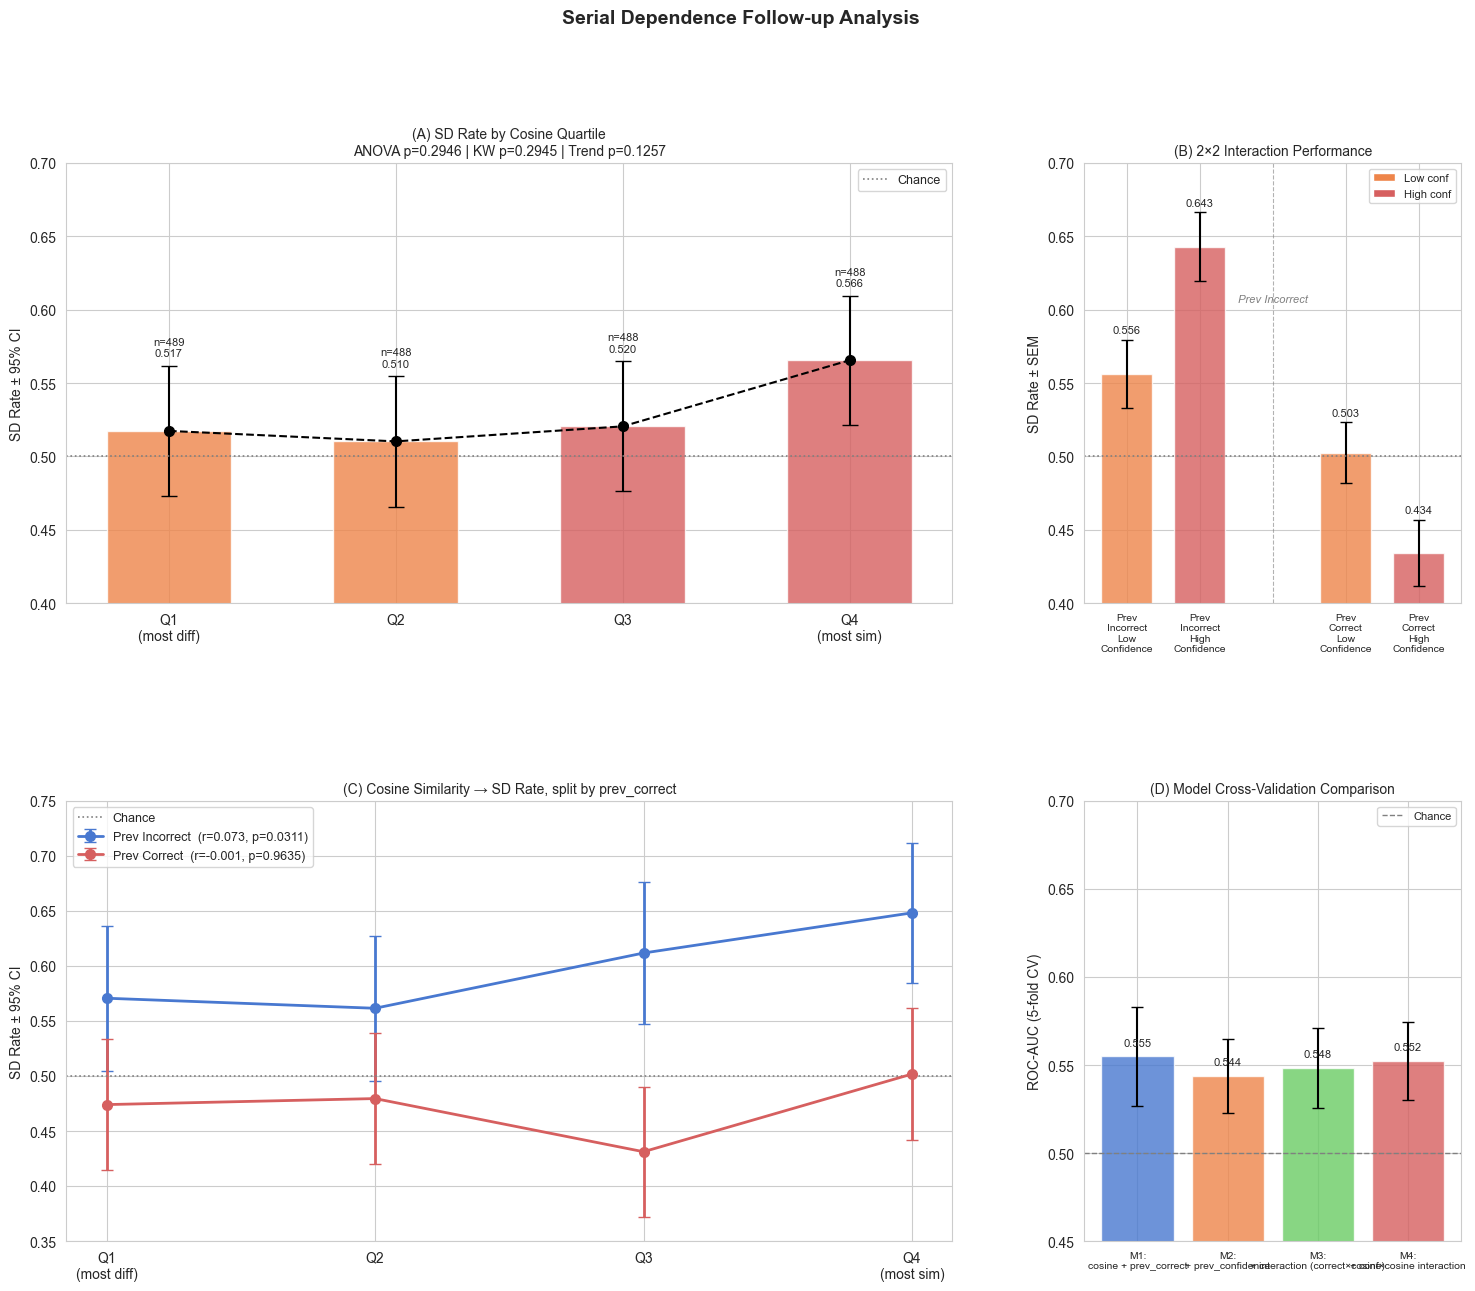

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

try:
    import pingouin as pg
    HAS_PINGOUIN = True
except ImportError:
    HAS_PINGOUIN = False
    print("Note: pingouin not installed — using scipy for post-hoc tests.")

# Load and prepare data
print("Loading data...")
df = pd.read_pickle("all_data_et.pkl")

df_all = df[df["same_session"] == 1].copy()
df_all = df_all.dropna(subset=["n_min_1_response", "response", "stimulus", "n_min_1_stimulus"])

df_all["resp_binary"]      = (df_all["response"] == "malignant").astype(int)
df_all["prev_resp_binary"] = (df_all["n_min_1_response"] == "malignant").astype(int)
df_all["stim_binary"]      = (df_all["stimulus"] == "malignant").astype(int)
df_all["prev_stim_binary"] = (df_all["n_min_1_stimulus"] == "malignant").astype(int)
df_all["stim_changed"]     = (df_all["stim_binary"] != df_all["prev_stim_binary"]).astype(int)

# Filter for category switch trials
df_sd = df_all[df_all["stim_changed"] == 1].copy()
df_sd["sd_event"] = (df_sd["resp_binary"] == df_sd["prev_resp_binary"]).astype(int)

conf_map = {"high": 1, "low": 0}
df_sd["prev_confidence_num"] = df_sd["n_min_1_confidence"].map(conf_map)
df_sd["rt_s"] = df_sd["mouse_response_s"] - df_sd["stimulus_onset_s"]

print(f"  Different-category trials: {len(df_sd)}")
print(f"  SD rate: {df_sd['sd_event'].mean():.3f}")

# ANOVA on cosine similarity quartiles
print("\n── ANOVA: Cosine Similarity Quartiles ──")

df_sd["cos_quartile"] = pd.qcut(
    df_sd["cosine_similarity"], q=4,
    labels=["Q1\n(most diff)", "Q2", "Q3", "Q4\n(most sim)"]
)

groups = [
    df_sd.loc[df_sd["cos_quartile"] == q, "sd_event"].values
    for q in ["Q1\n(most diff)", "Q2", "Q3", "Q4\n(most sim)"]
]
group_labels = ["Q1 (most diff)", "Q2", "Q3", "Q4 (most sim)"]

f_stat, p_anova = stats.f_oneway(*groups)
print(f"\n  One-way ANOVA: F = {f_stat:.4f},  p = {p_anova:.4f}")

h_stat, p_kruskal = stats.kruskal(*groups)
print(f"  Kruskal-Wallis: H = {h_stat:.4f},  p = {p_kruskal:.4f}")

bin_stats = df_sd.groupby("cos_quartile", observed=True)["sd_event"].agg(
    mean="mean", sem=lambda x: x.sem(), n="count", std="std"
).reset_index()
bin_stats["ci95"] = 1.96 * bin_stats["sem"]

print("\n  SD rate per quartile:")
for _, row in bin_stats.iterrows():
    print(f"    {str(row['cos_quartile']):20s}  "
          f"mean={row['mean']:.4f}  sem={row['sem']:.4f}  n={int(row['n'])}")

# Pairwise follow-up tests
print("\n  Post-hoc pairwise tests (Bonferroni-corrected):")
n_comparisons = 6  
quartile_keys = ["Q1\n(most diff)", "Q2", "Q3", "Q4\n(most sim)"]
posthoc_results = []
for i in range(len(quartile_keys)):
    for j in range(i+1, len(quartile_keys)):
        g1 = df_sd.loc[df_sd["cos_quartile"] == quartile_keys[i], "sd_event"]
        g2 = df_sd.loc[df_sd["cos_quartile"] == quartile_keys[j], "sd_event"]
        stat, p_raw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        p_corrected = min(p_raw * n_comparisons, 1.0)
        sig = "*" if p_corrected < 0.05 else ("†" if p_corrected < 0.10 else "ns")
        posthoc_results.append({
            "comparison": f"{group_labels[i]} vs {group_labels[j]}",
            "U": stat, "p_raw": p_raw, "p_bonf": p_corrected, "sig": sig
        })
        print(f"    {group_labels[i]:18s} vs {group_labels[j]:18s}  "
              f"p_raw={p_raw:.4f}  p_bonf={p_corrected:.4f}  {sig}")

# Trend test
quartile_ord_map = {"Q1\n(most diff)": 1, "Q2": 2, "Q3": 3, "Q4\n(most sim)": 4}
df_sd["cos_q_ord"] = df_sd["cos_quartile"].map(quartile_ord_map)
r_trend, p_trend = stats.spearmanr(df_sd["cos_q_ord"], df_sd["sd_event"])
print(f"\n  Linear trend (Spearman rank correlation): r = {r_trend:.4f}, p = {p_trend:.4f}")

# Analysis by previous accuracy and confidence
print("\n── Anchor Strength Hypothesis ──")

for val, label in [(0, "prev INCORRECT"), (1, "prev CORRECT")]:
    sub = df_sd[df_sd["correct"] == val]["sd_event"]
    print(f"\n  {label}: SD rate = {sub.mean():.4f}  (n={len(sub)})")

stat, p = stats.mannwhitneyu(
    df_sd[df_sd["correct"] == 1]["sd_event"],
    df_sd[df_sd["correct"] == 0]["sd_event"],
    alternative="two-sided"
)
print(f"  prev_correct effect: MWU p = {p:.4f}")

# 2x2 breakdown
print("\n  2×2 SD rate table: prev_correct × prev_confidence")
print(f"  {'':30s}  {'Low conf':>10}  {'High conf':>10}")
for correct_val, correct_label in [(0, "prev INCORRECT"), (1, "prev CORRECT   ")]:
    row_str = f"  {correct_label:30s}"
    for conf_val in [0, 1]:
        mask = (df_sd["correct"] == correct_val) & (df_sd["prev_confidence_num"] == conf_val)
        sub = df_sd[mask]["sd_event"]
        row_str += f"  {sub.mean():.3f} (n={len(sub):4d})"
    print(row_str)

# Check cosine correlation within incorrect/correct trials
for val, label in [(0, "prev INCORRECT"), (1, "prev CORRECT")]:
    sub = df_sd[df_sd["correct"] == val].dropna(subset=["cosine_similarity"])
    r, p = stats.spearmanr(sub["cosine_similarity"], sub["sd_event"])
    print(f"\n  Cosine sim → SD, {label}: r = {r:.4f}, p = {p:.4f}")

# Set up interaction terms for logistic models
df_sd["prev_correct_x_cosine"] = df_sd["correct"] * df_sd["cosine_similarity"]
df_sd["prev_conf_x_cosine"]    = df_sd["prev_confidence_num"] * df_sd["cosine_similarity"]

# Fit models to see if interaction terms boost performance
print("\n── Model Comparison ──")

df_mod = df_sd[["sd_event", "cosine_similarity", "correct",
                "prev_confidence_num", "prev_correct_x_cosine",
                "prev_conf_x_cosine", "rt_s"]].dropna()
y_mod = df_mod["sd_event"]
cv5   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_specs = {
    "M1: cosine + prev_correct": ["cosine_similarity", "correct"],
    "M2: + prev_confidence": ["cosine_similarity", "correct", "prev_confidence_num"],
    "M3: + interaction (correct×cosine)": ["cosine_similarity", "correct", "prev_confidence_num", "prev_correct_x_cosine"],
    "M4: + conf×cosine interaction": ["cosine_similarity", "correct", "prev_confidence_num", "prev_correct_x_cosine", "prev_conf_x_cosine"],
}

model_aucs = {}
for name, feats in model_specs.items():
    X_mod = df_mod[feats]
    pipe = Pipeline([("sc", StandardScaler()),
                     ("lr", LogisticRegression(max_iter=500, class_weight="balanced"))])
    aucs = cross_val_score(pipe, X_mod, y_mod, cv=cv5, scoring="roc_auc")
    model_aucs[name] = (aucs.mean(), aucs.std())
    print(f"  {name:45s}  AUC = {aucs.mean():.4f} ± {aucs.std():.4f}")

# Plotting results
sns.set_style("whitegrid")
pal = sns.color_palette("muted")
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Serial Dependence Follow-up Analysis", fontsize=14, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# (A) Cosine quartile bar plot
ax_a = fig.add_subplot(gs[0, :2])
x_pos  = np.arange(len(bin_stats))
colors = [pal[1], pal[1], pal[3], pal[3]]
bars   = ax_a.bar(x_pos, bin_stats["mean"], yerr=bin_stats["ci95"], color=colors, alpha=0.8, capsize=6, width=0.55)
ax_a.axhline(0.5, color="gray", ls=":", lw=1.2, label="Chance")
ax_a.plot(x_pos, bin_stats["mean"], "k--o", lw=1.5, ms=7, zorder=5)
ax_a.set_xticks(x_pos)
ax_a.set_xticklabels(bin_stats["cos_quartile"].astype(str), fontsize=10)
ax_a.set_ylabel("SD Rate ± 95% CI")
ax_a.set_ylim(0.40, 0.70)
ax_a.set_title(f"(A) SD Rate by Cosine Quartile\nANOVA p={p_anova:.4f} | KW p={p_kruskal:.4f} | Trend p={p_trend:.4f}", fontsize=10)
ax_a.legend(fontsize=9)

for bar, (_, row) in zip(bars, bin_stats.iterrows()):
    ax_a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + row["ci95"] + 0.005,
              f"n={int(row['n'])}\n{row['mean']:.3f}", ha="center", va="bottom", fontsize=8)

# Significance bars for post-hoc pairs
sig_pairs = [(r["comparison"], r["p_bonf"], r["sig"]) for r in posthoc_results if r["sig"] != "ns"]
y_bracket = 0.635
for comp, p_b, sig in sig_pairs:
    parts = comp.split(" vs ")
    try:
        i1 = group_labels.index(parts[0])
        i2 = group_labels.index(parts[1])
        ax_a.annotate("", xy=(i2, y_bracket), xytext=(i1, y_bracket), arrowprops=dict(arrowstyle="-", color="black", lw=1.2))
        ax_a.text((i1 + i2) / 2, y_bracket + 0.003, f"{sig} p={p_b:.3f}", ha="center", fontsize=8)
        y_bracket += 0.022
    except ValueError:
        pass

# (B) 2x2 Breakdown of prior state
ax_b = fig.add_subplot(gs[0, 2])
table_data = []
for correct_val, correct_label in [(0, "Prev\nIncorrect"), (1, "Prev\nCorrect")]:
    for conf_val, conf_label in [(0, "Low\nConfidence"), (1, "High\nConfidence")]:
        mask = (df_sd["correct"] == correct_val) & (df_sd["prev_confidence_num"] == conf_val)
        sub = df_sd[mask]["sd_event"]
        table_data.append({
            "prev_correct": correct_label, "prev_confidence": conf_label,
            "SD_rate": sub.mean(), "sem": sub.sem(), "n": len(sub)
        })
table_df = pd.DataFrame(table_data)

x = np.array([0, 1, 3, 4])
bar_colors = [pal[1], pal[3], pal[1], pal[3]]
bars_b = ax_b.bar(x, table_df["SD_rate"], yerr=table_df["sem"], color=bar_colors, alpha=0.8, capsize=4, width=0.7)
ax_b.axhline(0.5, color="gray", ls=":", lw=1.2)
ax_b.set_xticks(x)
ax_b.set_xticklabels([f"{r['prev_correct']}\n{r['prev_confidence']}" for _, r in table_df.iterrows()], fontsize=7.5)
ax_b.set_ylabel("SD Rate ± SEM")
ax_b.set_ylim(0.40, 0.70)
ax_b.set_title("(B) 2×2 Interaction Performance", fontsize=10)

for bar, (_, row) in zip(bars_b, table_df.iterrows()):
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + row["sem"] + 0.003, f"{row['SD_rate']:.3f}", ha="center", va="bottom", fontsize=8)
ax_b.axvline(2, color="gray", ls="--", lw=0.8, alpha=0.6)
ax_b.text(0.5, 0.685, "Prev Incorrect", transform=ax_b.transAxes, ha="center", fontsize=8, style="italic", color="gray")
ax_b.legend(handles=[Patch(facecolor=pal[1], label="Low conf"), Patch(facecolor=pal[3], label="High conf")], fontsize=8)

# (C) Cosine effects split by accuracy group
ax_c = fig.add_subplot(gs[1, :2])
for val, label, color in [(0, "Prev Incorrect", pal[0]), (1, "Prev Correct", pal[3])]:
    sub = df_sd[df_sd["correct"] == val].copy()
    sub["cos_q"] = pd.qcut(sub["cosine_similarity"], q=4, labels=[1, 2, 3, 4])
    bin_r = sub.groupby("cos_q", observed=True)["sd_event"].agg(mean="mean", sem=lambda x: x.sem()).reset_index()
    r, p = stats.spearmanr(sub["cosine_similarity"], sub["sd_event"])
    ax_c.errorbar(bin_r["cos_q"].astype(int), bin_r["mean"], yerr=1.96 * bin_r["sem"], fmt="o-", color=color, lw=2, ms=7, capsize=4,
                  label=f"{label}  (r={r:.3f}, p={p:.4f})")

ax_c.axhline(0.5, color="gray", ls=":", lw=1.2, label="Chance")
ax_c.set_xticks([1, 2, 3, 4])
ax_c.set_xticklabels(["Q1\n(most diff)", "Q2", "Q3", "Q4\n(most sim)"])
ax_c.set_ylabel("SD Rate ± 95% CI")
ax_c.set_ylim(0.35, 0.75)
ax_c.set_title("(C) Cosine Similarity → SD Rate, split by prev_correct", fontsize=10)
ax_c.legend(fontsize=9)

# (D) Logistic regression model comparison
ax_d = fig.add_subplot(gs[1, 2])
names  = [n.replace(": ", ":\n") for n in model_aucs]
means  = [v[0] for v in model_aucs.values()]
stds   = [v[1] for v in model_aucs.values()]
bars_d = ax_d.bar(range(len(names)), means, yerr=stds, color=[pal[i % len(pal)] for i in range(len(names))], alpha=0.8, capsize=4)
ax_d.axhline(0.5, color="gray", ls="--", lw=1, label="Chance")
ax_d.set_xticks(range(len(names)))
ax_d.set_xticklabels(names, fontsize=7.5)
ax_d.set_ylim(0.45, 0.70)
ax_d.set_ylabel("ROC-AUC (5-fold CV)")
ax_d.set_title("(D) Model Cross-Validation Comparison", fontsize=10)
ax_d.legend(fontsize=8)
for bar, val in zip(bars_d, means):
    ax_d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.savefig("sd_followup_results.png", dpi=150, bbox_inches="tight")
print("\nFigure saved: sd_followup_results.png")